In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from matplotlib.lines import Line2D

kb = 8.617333e-2  # meV/K

# ── thermodynamic helpers (Dv-based) ─────────────────────────
def _get_energies_Dv(Dv_arr, energies, Dv):
    """Get energy branches at the closest Dv value."""
    idx = np.argmin(np.abs(Dv_arr - Dv))
    e   = energies[idx]
    return e[~np.isnan(e)]

def F_Dv(Dv_arr, energies, Dv, T):
    kbT = kb * T
    e   = _get_energies_Dv(Dv_arr, energies, Dv)
    x   = e / kbT
    log1pexp = np.where(x >= 0, np.log1p(np.exp(-x)), -x + np.log1p(np.exp(x)))
    return -kbT * np.sum(log1pexp)

def S_Dv(Dv_arr, energies, Dv, T):
    kbT = kb * T
    e   = _get_energies_Dv(Dv_arr, energies, Dv)
    x   = e / kbT
    log_term = np.where(x >= 0, np.log1p(np.exp(-x)), -x + np.log1p(np.exp(x)))
    occ_term = x / (np.exp(np.clip(x, -500, 500)) + 1)
    return kb * np.sum(log_term + occ_term)

def U_Dv(Dv_arr, energies, Dv, T):
    kbT = kb * T
    e   = _get_energies_Dv(Dv_arr, energies, Dv)
    f   = 1.0 / (np.exp(np.clip(e / kbT, -500, 500)) + 1.0)
    return np.sum(e * f)

def find_T_for_entropy_Dv(Dv_arr, energies, Dv, S_target, T_lo=1e-6, T_hi=100.0):
    f = lambda T: S_Dv(Dv_arr, energies, Dv, T) - S_target
    while f(T_hi) < 0 and T_hi < 1e5:
        T_hi *= 10.0
    if f(T_lo) * f(T_hi) > 0:
        return T_lo if abs(f(T_lo)) < abs(f(T_hi)) else T_hi
    return brentq(f, T_lo, T_hi, xtol=1e-10, rtol=1e-10)


# ── Otto cycle over Dv ────────────────────────────────────────
def otto_Dv(Dv_arr, energies, Dv1, Dv2, Tc, Th):
    """
    Quantum Otto cycle with Dv as the work parameter instead of phi.

    Stroke A→B  adiabatic:   (Dv1, Th)     → (Dv2, Talpha)
    Stroke B→C  isochoric:   (Dv2, Talpha) → (Dv2, Tc)
    Stroke C→D  adiabatic:   (Dv2, Tc)     → (Dv1, Tbeta)
    Stroke D→A  isochoric:   (Dv1, Tbeta)  → (Dv1, Th)
    """
    S_A = S_Dv(Dv_arr, energies, Dv1, Th)
    S_C = S_Dv(Dv_arr, energies, Dv2, Tc)

    Talpha = find_T_for_entropy_Dv(Dv_arr, energies, Dv2, S_A)
    Tbeta  = find_T_for_entropy_Dv(Dv_arr, energies, Dv1, S_C)

    res_alpha = abs(S_Dv(Dv_arr, energies, Dv2, Talpha) - S_A)
    res_beta  = abs(S_Dv(Dv_arr, energies, Dv1, Tbeta)  - S_C)
    if res_alpha > 1e-6 or res_beta > 1e-6:
        print(f"  WARNING: adiabat residuals  α={res_alpha:.2e}  β={res_beta:.2e}")

    UA = U_Dv(Dv_arr, energies, Dv1, Th)
    UB = U_Dv(Dv_arr, energies, Dv2, Talpha)
    UC = U_Dv(Dv_arr, energies, Dv2, Tc)
    UD = U_Dv(Dv_arr, energies, Dv1, Tbeta)

    WAB   = UA - UB
    WCD   = UC - UD
    Qcold = UC - UB
    Qhot  = UA - UD
    WT    = WAB + WCD

    return WAB, WCD, WT, Qhot, Qcold, Talpha, Tbeta


# ── sweep Dv2 ─────────────────────────────────────────────────
def otto_sweep_Dv(Dv_arr, energies, Dv1, Tc, Th, save=False):
    """Sweep Dv2 over all values and plot Qhot, Qcold, WT, Talpha, Tbeta."""
    n       = len(Dv_arr)
    WT_arr     = np.zeros(n)
    Qhot_arr   = np.zeros(n)
    Qcold_arr  = np.zeros(n)
    Talpha_arr = np.zeros(n)
    Tbeta_arr  = np.zeros(n)

    for i, Dv2 in enumerate(Dv_arr):
        _, _, WT, Qhot, Qcold, Talpha, Tbeta = otto_Dv(
            Dv_arr, energies, Dv1, Dv2, Tc, Th)
        WT_arr[i]     = WT
        Qhot_arr[i]   = Qhot
        Qcold_arr[i]  = Qcold
        Talpha_arr[i] = Talpha
        Tbeta_arr[i]  = Tbeta

    # plot 1: Qhot, Qcold, WT
    fig, axes = plt.subplots(3, 1, figsize=(8, 9), sharex=True)
    for ax, arr, label, color in [
        (axes[0], Qhot_arr,  r"$Q_\mathrm{hot}$  (meV)",  "crimson"),
        (axes[1], Qcold_arr, r"$Q_\mathrm{cold}$ (meV)",  "royalblue"),
        (axes[2], WT_arr,    r"$W_T$  (meV)",              "seagreen"),
    ]:
        ax.plot(Dv_arr, arr, color=color, lw=1.8)
        ax.axhline(0, color="gray", lw=0.7, ls="--", alpha=0.5)
        ax.set_ylabel(label, fontsize=12)
        ax.grid(alpha=0.2)
    axes[2].set_xlabel(r"$\Delta_v^{(2)}$  (meV)", fontsize=12)
    fig.suptitle(fr"Quantum Otto Cycle  —  $\Delta_v^{{(1)}}$={Dv1:.3f} meV, $T_c$={Tc} K, $T_h$={Th} K",
                 fontsize=13)
    plt.tight_layout()
    if save: plt.savefig("otto_sweep_Dv.png", dpi=150, bbox_inches="tight")
    plt.show()

    # plot 2: adiabatic temperatures
    fig2, ax2 = plt.subplots(figsize=(8, 4))
    ax2.plot(Dv_arr, Talpha_arr, color="darkorange", lw=1.8, label=r"$T_\alpha$")
    ax2.plot(Dv_arr, Tbeta_arr,  color="purple",     lw=1.8, label=r"$T_\beta$")
    ax2.axhline(Th, color="crimson",   lw=0.9, ls="--", alpha=0.6, label=f"$T_h={Th}$ K")
    ax2.axhline(Tc, color="royalblue", lw=0.9, ls="--", alpha=0.6, label=f"$T_c={Tc}$ K")
    ax2.set_xlabel(r"$\Delta_v^{(2)}$  (meV)", fontsize=12)
    ax2.set_ylabel("Temperature (K)", fontsize=12)
    ax2.set_title(fr"Otto adiabatic temperatures  —  $\Delta_v^{{(1)}}$={Dv1:.3f} meV", fontsize=12)
    ax2.legend(fontsize=10); ax2.grid(alpha=0.2)
    plt.tight_layout()
    if save:
        plt.savefig("otto_temperatures_Dv.png", dpi=150, bbox_inches="tight")
        np.savetxt("otto_sweep_Dv.dat",
                   np.column_stack([Dv_arr, Qhot_arr, Qcold_arr, WT_arr,
                                    Talpha_arr, Tbeta_arr]),
                   header="Dv2(meV)  Qhot(meV)  Qcold(meV)  WT(meV)  Talpha(K)  Tbeta(K)",
                   comments="# ")
    plt.show()

    return Dv_arr, Qhot_arr, Qcold_arr, WT_arr, Talpha_arr, Tbeta_arr


# ── Dv1 vs Dv2 heatmaps of Talpha and Tbeta ──────────────────
def compute_T_maps_Dv(Dv_arr, energies, Tc, Th, n=60):
    """Compute Talpha and Tbeta over Dv1 x Dv2 grid."""
    Dv_grid    = np.linspace(Dv_arr.min(), Dv_arr.max(), n)
    Talpha_map = np.full((n, n), np.nan)
    Tbeta_map  = np.full((n, n), np.nan)

    for i, Dv1 in enumerate(Dv_grid):
        if i % 10 == 0: print(f"    row {i}/{n}")
        S_A = S_Dv(Dv_arr, energies, Dv1, Th)
        for j, Dv2 in enumerate(Dv_grid):
            S_C = S_Dv(Dv_arr, energies, Dv2, Tc)
            Talpha_map[i, j] = find_T_for_entropy_Dv(Dv_arr, energies, Dv2, S_A)
            Tbeta_map[i, j]  = find_T_for_entropy_Dv(Dv_arr, energies, Dv1, S_C)

    return Dv_grid, Talpha_map, Tbeta_map





# ── Otto heatmap: Dv1 vs Dv2, color = WT ─────────────────────
def otto_heatmap_Dv(Dv_arr, energies, Tc, Th, n=60, save=False):
    """Dv1 vs Dv2 heatmap of WT with regime boundary contours."""
    Dv_grid   = np.linspace(Dv_arr.min(), Dv_arr.max(), n)
    WT_map    = np.full((n, n), np.nan)
    Qhot_map  = np.full((n, n), np.nan)
    Qcold_map = np.full((n, n), np.nan)
    regime_map = np.zeros((n, n), dtype=int)

    print("Computing Otto Dv heatmap...")
    for i, Dv1 in enumerate(Dv_grid):
        if i % 10 == 0:
            print(f"    row {i}/{n}")
        for j, Dv2 in enumerate(Dv_grid):
            _, _, WT, Qhot, Qcold, _, _ = otto_Dv(Dv_arr, energies, Dv1, Dv2, Tc, Th)
            WT_map[i, j]    = WT*1000
            Qhot_map[i, j]  = Qhot
            Qcold_map[i, j] = Qcold
            if   Qhot > 0 and Qcold < 0 and WT > 0: regime_map[i, j] = 1
            elif Qhot < 0 and Qcold > 0 and WT < 0: regime_map[i, j] = 2
            elif Qhot > 0 and Qcold < 0 and WT < 0: regime_map[i, j] = 3
            elif Qhot < 0 and Qcold < 0 and WT < 0: regime_map[i, j] = 4

    WT_masked = np.where(regime_map > 0, WT_map, np.nan)

    # Get min and max values for the colorbar (excluding NaN)
    vmin = np.nanmin(WT_masked)
    vmax = np.nanmax(WT_masked)

    # Use TwoSlopeNorm to put white at zero
    from matplotlib.colors import TwoSlopeNorm
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.pcolormesh(Dv_grid, Dv_grid, WT_masked,
                       cmap="RdBu_r", norm=norm, shading="auto")

    # Add colorbar with appropriate ticks
    cbar = plt.colorbar(im, ax=ax, label=r"$W_T$  ($\mu$eV)")
    cbar.ax.set_ylabel(r'$W_T$  ($\mu$eV)', fontsize=30,color= 'blue')  # Increase label size
    cbar.ax.tick_params(labelsize=25)  # Increase tick label size

    # Set colorbar ticks to include min and max values
    cbar_ticks = [vmin, 0, vmax]
    # Add some intermediate ticks for better readability
    if vmin < 0 and vmax > 0:
        # Add one intermediate negative and positive tick
        mid_neg = vmin / 2 if vmin < 0 else None
        mid_pos = vmax / 2 if vmax > 0 else None
        if mid_neg is not None and mid_neg > vmin:
            cbar_ticks.append(mid_neg)
        if mid_pos is not None and mid_pos < vmax:
            cbar_ticks.append(mid_pos)
    cbar_ticks = sorted(set(cbar_ticks))  # Remove duplicates and sort
    cbar.set_ticks(cbar_ticks)
    # Format tick labels with appropriate precision
    cbar.ax.set_yticklabels([f'{tick:.1f}' for tick in cbar_ticks])

    # Optional: Add a white line at zero to emphasize it
    cbar.ax.axhline(y=0, color='black', linewidth=1, linestyle='-', alpha=0.5)

    # For axis ticks
    ax.tick_params(axis='both', labelsize=30)  # Increase axis tick label size

    cs_kw = dict(linewidths=2)
    ax.contour(Dv_grid, Dv_grid, WT_map,    levels=[0], colors="black",   **cs_kw)
    ax.contour(Dv_grid, Dv_grid, Qhot_map,  levels=[0], colors="crimson",
               linestyles="--", **cs_kw)
    ax.contour(Dv_grid, Dv_grid, Qcold_map, levels=[0], colors="purple",
               linestyles="--", **cs_kw)

    ax.legend(handles=[
        Line2D([0],[0], color='black',   lw=2, ls='-',  label=r'$W_T=0$'),
        Line2D([0],[0], color='crimson', lw=2, ls='--', label=r'$Q_\mathrm{hot}=0$'),
        Line2D([0],[0], color='purple',  lw=2, ls='--', label=r'$Q_\mathrm{cold}=0$'),
    ], fontsize=20, loc='upper center')

    ax.set_xlabel(r"$\Delta_{v2}$  (meV)", fontsize=40)
    ax.set_ylabel(r"$\Delta_{v1}$  (meV)", fontsize=40)
    #ax.set_title(fr"Otto $W_T(\Delta_v^{{(1)}},\Delta_v^{{(2)}})$  —  $T_c={Tc}$ K, $T_h={Th}$ K",
    #             fontsize=13)
    plt.tight_layout()

    plt.savefig("3Fig5a.png", dpi=150, bbox_inches="tight")

    plt.show()
    return Dv_grid, WT_masked, regime_map


from matplotlib.lines import Line2D
import matplotlib.ticker as ticker

def combined_dv_heatmap_otto(data_Dv, Dv_arr, energies, Tc, Th, n=80, save=False):
    """
    Create a combined heatmap showing all three regimes with different colormaps:
    1. Heat engine: eta/eta_Carnot (plasma colormap)
    2. Refrigerator: COP/COP_Carnot (cool colormap)
    3. Cold pump: COP = |Qcold|/|WT| (hot_r colormap, capped at 50)

    Contour lines: WT=0 (white), Qhot=0 (red), Qcold=0 (blue)
    Three separate colorbars stacked vertically on the RIGHT side.
    Invalid regions (no regime) are shown in white.

    Parameters:
    -----------
    data_Dv : Dv-dependent dataset
    Dv_arr : array of Dv values
    energies : energies array for each Dv
    Tc, Th : temperatures
    n : grid resolution
    save : whether to save the figure
    """
    eta_C = 1 - Tc / Th
    COP_C = Tc / (Th - Tc)

    # Create grid for Dv1 and Dv2
    Dv1_grid = np.linspace(Dv_arr.min(), Dv_arr.max(), n)
    Dv2_grid = np.linspace(Dv_arr.min(), Dv_arr.max(), n)

    # Initialize maps
    combined_map = np.full((n, n), np.nan)
    regime_map = np.zeros((n, n), dtype=int)
    WT_map = np.full((n, n), np.nan)
    Qhot_map = np.full((n, n), np.nan)
    Qcold_map = np.full((n, n), np.nan)

    # Store values for each regime separately
    engine_values = np.full((n, n), np.nan)
    refrigerator_values = np.full((n, n), np.nan)
    coldpump_values = np.full((n, n), np.nan)

    print("Computing combined Otto Dv heatmap...")
    for i, Dv1 in enumerate(Dv1_grid):
        if i % 10 == 0:
            print(f"  row {i}/{n} (Dv1 = {Dv1:.3f} meV)")
        for j, Dv2 in enumerate(Dv2_grid):
            # Use your otto_Dv function
            WAB, WCD, WT, Qhot, Qcold, Talpha, Tbeta = otto_Dv(
                Dv_arr, energies, Dv1, Dv2, Tc, Th)

            WT_map[i, j] = WT
            Qhot_map[i, j] = Qhot
            Qcold_map[i, j] = Qcold

            # Heat Engine regime: Qhot > 0, Qcold < 0, WT > 0
            if Qhot > 0 and Qcold < 0 and WT > 0:
                regime_map[i, j] = 1
                engine_values[i, j] = (WT / Qhot) / eta_C
                combined_map[i, j] = engine_values[i, j]

            # Refrigerator regime: Qhot < 0, Qcold > 0, WT < 0
            elif Qhot < 0 and Qcold > 0 and WT < 0:
                regime_map[i, j] = 2
                refrigerator_values[i, j] = (abs(Qcold) / abs(WT)) / COP_C
                combined_map[i, j] = refrigerator_values[i, j]

            # Cold Pump regime: Qhot > 0, Qcold < 0, WT < 0
            elif Qhot > 0 and Qcold < 0 and WT < 0:
                regime_map[i, j] = 3
                coldpump_values[i, j] = min(abs(Qcold) / abs(WT), 50)
                combined_map[i, j] = coldpump_values[i, j]

    # Create RGB image with white for invalid regions
    rgb_image = np.ones((n, n, 3))  # Start with white (1,1,1)

    # Get colormaps
    plasma_cmap = plt.cm.plasma
    cool_cmap = plt.cm.cool
    hot_cmap = plt.cm.hot_r

    engine_mask = (regime_map == 1)
    ref_mask = (regime_map == 2)
    pump_mask = (regime_map == 3)

    # Store colorbar info
    colorbar_info = {}

    if np.any(engine_mask):
        engine_vals = engine_values[engine_mask]
        vmin_engine = 0
        vmax_engine = np.nanmax(engine_vals)
        engine_norm = plt.Normalize(vmin=vmin_engine, vmax=vmax_engine)(engine_vals)
        engine_colors = plasma_cmap(engine_norm)
        rgb_image[engine_mask] = engine_colors[:, :3]
        colorbar_info['engine'] = {
            'vmin': vmin_engine,
            'vmax': vmax_engine,
            'cmap': plasma_cmap,
            'label': r"HE: $\eta_{\mathrm{HE}}/\eta_{\mathrm{c}}$"
        }
        print(f"HE: {vmin_engine:.3f} to {vmax_engine:.3f}")

    if np.any(ref_mask):
        ref_vals = refrigerator_values[ref_mask]
        vmin_ref = 0
        vmax_ref = np.nanmax(ref_vals)
        ref_norm = plt.Normalize(vmin=vmin_ref, vmax=vmax_ref)(ref_vals)
        ref_colors = cool_cmap(ref_norm)
        rgb_image[ref_mask] = ref_colors[:, :3]
        colorbar_info['refrigerator'] = {
            'vmin': vmin_ref,
            'vmax': vmax_ref,
            'cmap': cool_cmap,
            'label': r"RE: $\mathrm{COP_{\mathrm{RE}}}/\mathrm{COP}_{\mathrm{c}}$"
        }
        print(f"Refrigerator range: {vmin_ref:.3f} to {vmax_ref:.3f}")

    if np.any(pump_mask):
        pump_vals = coldpump_values[pump_mask]
        vmin_pump = 0
        vmax_pump = 50  # Capped at 50
        pump_norm = plt.Normalize(vmin=vmin_pump, vmax=vmax_pump)(pump_vals)
        pump_colors = hot_cmap(pump_norm)
        rgb_image[pump_mask] = pump_colors[:, :3]
        colorbar_info['coldpump'] = {
            'vmin': vmin_pump,
            'vmax': vmax_pump,
            'cmap': hot_cmap,
            'label': r"CP: $\mathrm{COP_{\mathrm{CP}}} $"
        }
        print(f"Cold Pump range: {vmin_pump:.3f} to {vmax_pump:.3f}")

    # Create figure with specific size
    fig = plt.figure(figsize=(10, 8))

    # Create main plot axis (positioned on the left)
    ax = fig.add_axes([0.1, 0.1, 0.6, 0.8])  # This makes the main plot square-like

    # Create three separate axes for colorbars on the right
    cbar_width = 0.03
    cbar_spacing = 0.05
    cbar_start_x = 0.73

    # Calculate positions for three colorbars
    cbar_height = 0.24
    total_height = 3 * cbar_height + 2 * cbar_spacing
    start_y = (0.8 - total_height) / 2 + 0.05

    # Top colorbar (Heat Engine)
    cbar_ax1 = fig.add_axes([cbar_start_x, start_y + 2*(cbar_height + cbar_spacing),
                             cbar_width, cbar_height])
    # Middle colorbar (Refrigerator)
    cbar_ax2 = fig.add_axes([cbar_start_x, start_y + (cbar_height + cbar_spacing),
                             cbar_width, cbar_height])
    # Bottom colorbar (Cold Pump)
    cbar_ax3 = fig.add_axes([cbar_start_x, start_y,
                             cbar_width, cbar_height])

    # Display the RGB image in the main plot
    im = ax.imshow(rgb_image, extent=[Dv2_grid.min(), Dv2_grid.max(),
                                       Dv1_grid.min(), Dv1_grid.max()],
                   origin='lower', aspect='equal')

    # Add contour lines
    cs_kw = dict(linewidths=2)
    ax.contour(Dv2_grid, Dv1_grid, WT_map, levels=[0],
               colors="white", linestyles="--", **cs_kw)
    ax.contour(Dv2_grid, Dv1_grid, Qhot_map, levels=[0],
               colors="red", linestyles="--", **cs_kw)
    ax.contour(Dv2_grid, Dv1_grid, Qcold_map, levels=[0],
               colors="blue", linestyles="--", **cs_kw)

    # Create colorbars in the dedicated axes
    if 'engine' in colorbar_info:
        engine_norm = plt.Normalize(colorbar_info['engine']['vmin'],
                                    colorbar_info['engine']['vmax'])
        engine_sm = plt.cm.ScalarMappable(cmap=colorbar_info['engine']['cmap'],
                                          norm=engine_norm)
        engine_sm.set_array([])
        cbar1 = plt.colorbar(engine_sm, cax=cbar_ax1, orientation='vertical')
        cbar1.set_label(colorbar_info['engine']['label'], fontsize=20, color="blue")
        cbar1.ax.tick_params(labelsize=20)

        # Add 4 equidistant ticks
        vmin = colorbar_info['engine']['vmin']
        vmax = colorbar_info['engine']['vmax']
        ticks = np.linspace(vmin, vmax, 4)
        cbar1.set_ticks(ticks)
        # Optional: format ticks to show 1 decimal place
        cbar1.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

    if 'refrigerator' in colorbar_info:
        ref_norm = plt.Normalize(colorbar_info['refrigerator']['vmin'],
                                 colorbar_info['refrigerator']['vmax'])
        ref_sm = plt.cm.ScalarMappable(cmap=colorbar_info['refrigerator']['cmap'],
                                       norm=ref_norm)
        ref_sm.set_array([])
        cbar2 = plt.colorbar(ref_sm, cax=cbar_ax2, orientation='vertical')
        cbar2.set_label(colorbar_info['refrigerator']['label'], fontsize=20, color="blue")
        cbar2.ax.tick_params(labelsize=20)

        # Add 4 equidistant ticks
        vmin = colorbar_info['refrigerator']['vmin']
        vmax = colorbar_info['refrigerator']['vmax']
        ticks = np.linspace(vmin, vmax, 4)
        cbar2.set_ticks(ticks)
        cbar2.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

    if 'coldpump' in colorbar_info:
        pump_norm = plt.Normalize(colorbar_info['coldpump']['vmin'],
                                  colorbar_info['coldpump']['vmax'])
        pump_sm = plt.cm.ScalarMappable(cmap=colorbar_info['coldpump']['cmap'],
                                        norm=pump_norm)
        pump_sm.set_array([])
        cbar3 = plt.colorbar(pump_sm, cax=cbar_ax3, orientation='vertical')
        cbar3.set_label(colorbar_info['coldpump']['label'], fontsize=20, color="blue")
        cbar3.ax.tick_params(labelsize=20)

        # Add 4 equidistant ticks
        vmin = colorbar_info['coldpump']['vmin']
        vmax = colorbar_info['coldpump']['vmax']
        ticks = np.linspace(vmin, vmax, 4)
        cbar3.set_ticks(ticks)
        cbar3.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

    # Legend (placed inside the main plot)
    legend_elements = [
        Line2D([0], [0], color="white", lw=2, ls="--", label=r"$W_T = 0$"),
        Line2D([0], [0], color="red", lw=2, ls="--", label=r"$Q_{\mathrm{hot}} = 0$"),
        Line2D([0], [0], color="blue", lw=2, ls="--", label=r"$Q_{\mathrm{cold}} = 0$")
    ]

    ax.legend(handles=legend_elements, fontsize=20, loc="upper center")

    ax.set_xlabel(r'$\Delta_{v2}$  (meV)', fontsize=40)
    ax.set_ylabel(r'$\Delta_{v1}$  (meV)', fontsize=40)
    ax.tick_params(axis='both', labelsize=30)

    # Add title (commented out to match combined_heatmap)
    #ax.set_title(
    #    fr"Otto Combined Performance Maps — $T_c={Tc}$ K, $T_h={Th}$ K",
    #    fontsize=12, pad=20)

    # Add statistics text box (optional, commented out)
    #n_engine = np.sum(regime_map == 1)
    #n_ref = np.sum(regime_map == 2)
    #n_pump = np.sum(regime_map == 3)
    #n_invalid = n*n - n_engine - n_ref - n_pump
    #stats_text = f"Points: Engine={n_engine}, Ref={n_ref}, Pump={n_pump}, Invalid={n_invalid}"
    #ax.text(0.02, 0.02, stats_text, transform=ax.transAxes,
    #        fontsize=8, verticalalignment='bottom',
    #        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.savefig("3Fig5b.png", dpi=150, bbox_inches="tight")
    print("Saved otto_combined_heatmap_Dv.png")

    plt.show()

    return Dv1_grid, Dv2_grid, combined_map, regime_map, WT_map, Qhot_map, Qcold_map, engine_values, refrigerator_values, coldpump_values



    row 0/200


/var/folders/j9/mv8r31ws7gd9xn1rn1c8gjnr0000gn/T/ipykernel_21383/4252710879.py:26: RuntimeWarning: overflow encountered in exp
  log_term = np.where(x >= 0, np.log1p(np.exp(-x)), -x + np.log1p(np.exp(x)))


    row 10/200
    row 20/200
    row 30/200
    row 40/200
    row 50/200
    row 60/200
    row 70/200
    row 80/200
    row 90/200
    row 100/200
    row 110/200
    row 120/200
    row 130/200
    row 140/200
    row 150/200
    row 160/200
    row 170/200
    row 180/200
    row 190/200


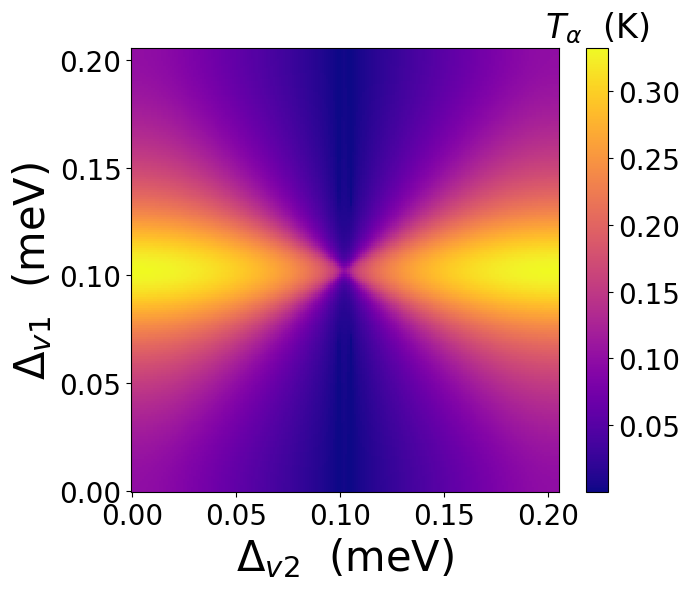

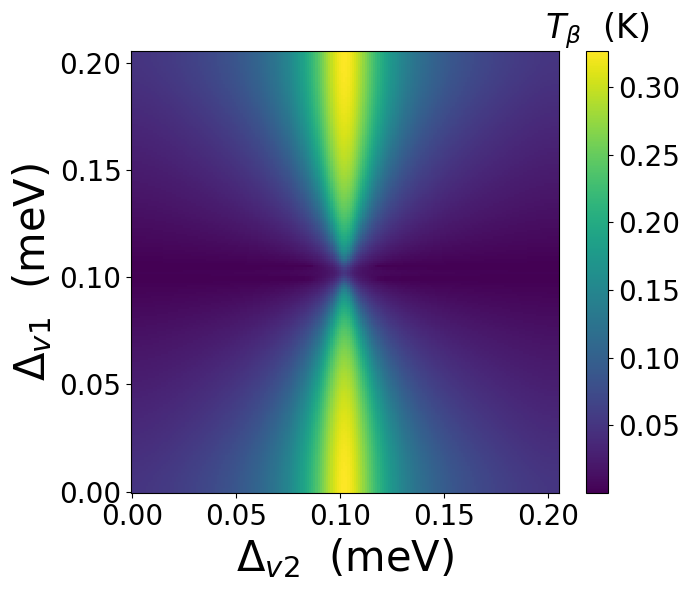

In [6]:
def plot_T_heatmaps_Dv(Dv_grid, Talpha_map, Tbeta_map, label, Tc, Th, save=False):
    for T_map, name, cmap in [
        (Talpha_map, r"$T_\alpha$", "plasma"),
        (Tbeta_map,  r"$T_\beta$",  "viridis"),
    ]:
        fig, ax = plt.subplots(figsize=(7, 6))
        im = ax.pcolormesh(Dv_grid, Dv_grid, T_map, cmap=cmap, shading="auto")

        cbar = plt.colorbar(im, ax=ax)
        cbar.ax.tick_params(labelsize=20)
        cbar.ax.set_ylabel("")                                         # remove rotated label
        cbar.ax.set_title(f"{name}  (K)", fontsize=24, pad=8)         # title sits above, horizontal

        ax.set_xlabel(r"$\Delta_{v2}$  (meV)", fontsize=30)
        ax.set_ylabel(r"$\Delta_{v1}$  (meV)", fontsize=30)
        ax.tick_params(axis='both', labelsize=20)
        plt.tight_layout()
        if save:
            tag = "alpha" if "alpha" in name else "beta"
            plt.savefig(f"T_{tag}_Dv_{label.replace(' ','_')}.png", dpi=150, bbox_inches="tight")
        plt.show()


# ── run ───────────────────────────────────────────────────────
Tc = 0.05
Th = 0.10

data     = np.loadtxt('ABS_MATBG_phi0_tillDv0205.dat', skiprows=1)
Dv_arr   = data[:, 0]
energies = data[:, 1:9]

Dv_grid, Talpha_map, Tbeta_map = compute_T_maps_Dv(
    Dv_arr, energies, Tc=Tc, Th=Th, n=200)



plot_T_heatmaps_Dv(Dv_grid, Talpha_map, Tbeta_map,
                   label="MATBG $\\phi=0$", Tc=Tc, Th=Th)

Computing Otto Dv heatmap...
    row 0/250


/var/folders/j9/mv8r31ws7gd9xn1rn1c8gjnr0000gn/T/ipykernel_21383/4252710879.py:26: RuntimeWarning: overflow encountered in exp
  log_term = np.where(x >= 0, np.log1p(np.exp(-x)), -x + np.log1p(np.exp(x)))


    row 10/250
    row 20/250
    row 30/250
    row 40/250
    row 50/250
    row 60/250
    row 70/250
    row 80/250
    row 90/250
    row 100/250
    row 110/250
    row 120/250
    row 130/250
    row 140/250
    row 150/250
    row 160/250
    row 170/250
    row 180/250
    row 190/250
    row 200/250
    row 210/250
    row 220/250
    row 230/250
    row 240/250


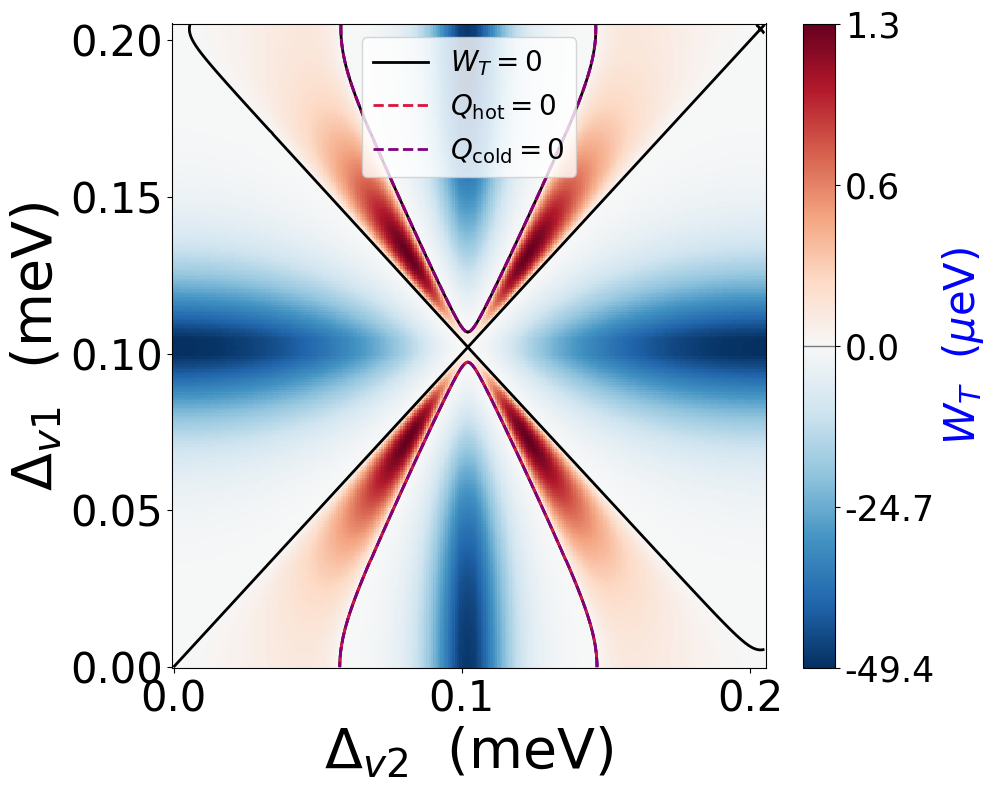

Computing combined Otto Dv heatmap...
  row 0/250 (Dv1 = 0.000 meV)


/var/folders/j9/mv8r31ws7gd9xn1rn1c8gjnr0000gn/T/ipykernel_21383/4252710879.py:26: RuntimeWarning: overflow encountered in exp
  log_term = np.where(x >= 0, np.log1p(np.exp(-x)), -x + np.log1p(np.exp(x)))


  row 10/250 (Dv1 = 0.008 meV)
  row 20/250 (Dv1 = 0.016 meV)
  row 30/250 (Dv1 = 0.025 meV)
  row 40/250 (Dv1 = 0.033 meV)
  row 50/250 (Dv1 = 0.041 meV)
  row 60/250 (Dv1 = 0.049 meV)
  row 70/250 (Dv1 = 0.058 meV)
  row 80/250 (Dv1 = 0.066 meV)
  row 90/250 (Dv1 = 0.074 meV)
  row 100/250 (Dv1 = 0.082 meV)
  row 110/250 (Dv1 = 0.091 meV)
  row 120/250 (Dv1 = 0.099 meV)
  row 130/250 (Dv1 = 0.107 meV)
  row 140/250 (Dv1 = 0.115 meV)
  row 150/250 (Dv1 = 0.123 meV)
  row 160/250 (Dv1 = 0.132 meV)
  row 170/250 (Dv1 = 0.140 meV)
  row 180/250 (Dv1 = 0.148 meV)
  row 190/250 (Dv1 = 0.156 meV)
  row 200/250 (Dv1 = 0.165 meV)
  row 210/250 (Dv1 = 0.173 meV)
  row 220/250 (Dv1 = 0.181 meV)
  row 230/250 (Dv1 = 0.189 meV)
  row 240/250 (Dv1 = 0.198 meV)
HE: 0.000 to 1.000
Refrigerator range: 0.000 to 1.000
Cold Pump range: 0.000 to 50.000


/var/folders/j9/mv8r31ws7gd9xn1rn1c8gjnr0000gn/T/ipykernel_21383/4127785289.py:255: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved otto_combined_heatmap_Dv.png


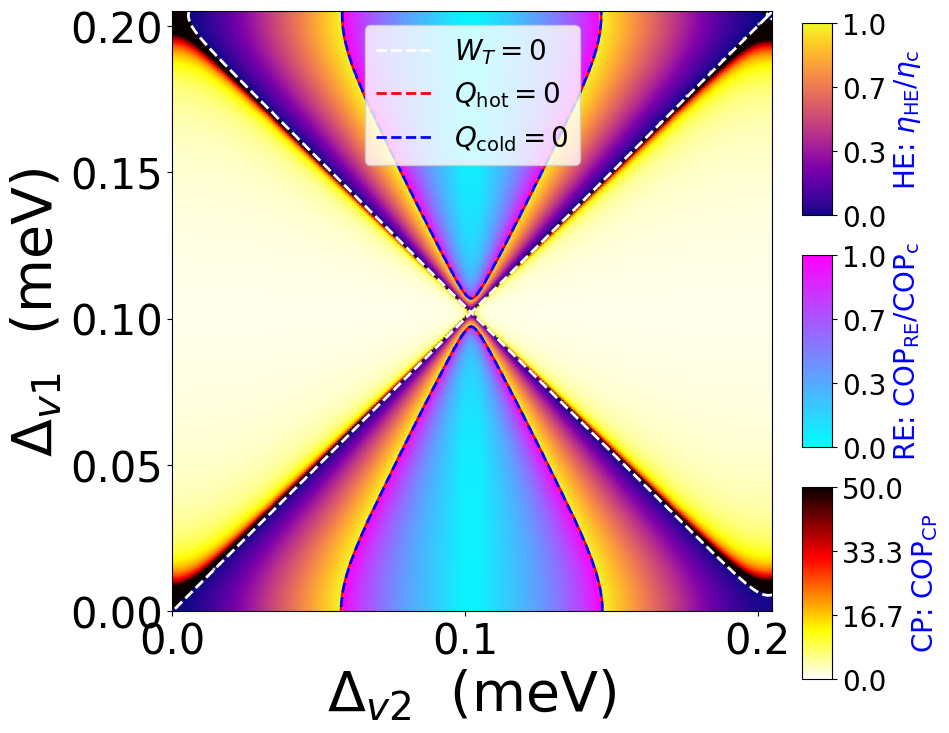

In [9]:

# Load data
data_Dv = np.loadtxt('ABS_MATBG_phi0_tillDv0205.dat', skiprows=1)
Dv_arr = data_Dv[:, 0]
energies = data_Dv[:, 1:9]

# Parameters
Tc = 0.05
Th = 0.1



# WT heatmap
otto_heatmap_Dv(Dv_arr, energies, Tc=Tc, Th=Th, n=250)


# Create heatmap
Dv1_grid, Dv2_grid, combined_map, regime_map, WT_map, Qhot_map, Qcold_map, engine_values, refrigerator_values, coldpump_values  = combined_dv_heatmap_otto(
    data_Dv, Dv_arr, energies, Tc, Th, n=250, save=False)